# Analysing Municipality Counts Across Dutch Provinces

In [1]:
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pandas as pd

## Inspecting the Dutch Provinces GeoPackage Layer

In [3]:
data_folder = '../../data'
fiona.listlayers(f'{data_folder}/nederland_admin_areas.gpkg')

['country', 'provinces', 'cities']

In [4]:
provinces = gpd.read_file(f'{data_folder}/nederland_admin_areas.gpkg', layer='provinces')
provinces.shape

(12, 6)

In [5]:
provinces.head(1)

,identificatie,naam,code,ligt_in_land_code,ligt_in_land_naam,geometry
0,PV22,Drenthe,22,6030,Nederland,"MULTIPOLYGON (((231437.815 516445.643, 231438...."


## Visualising the Provinces

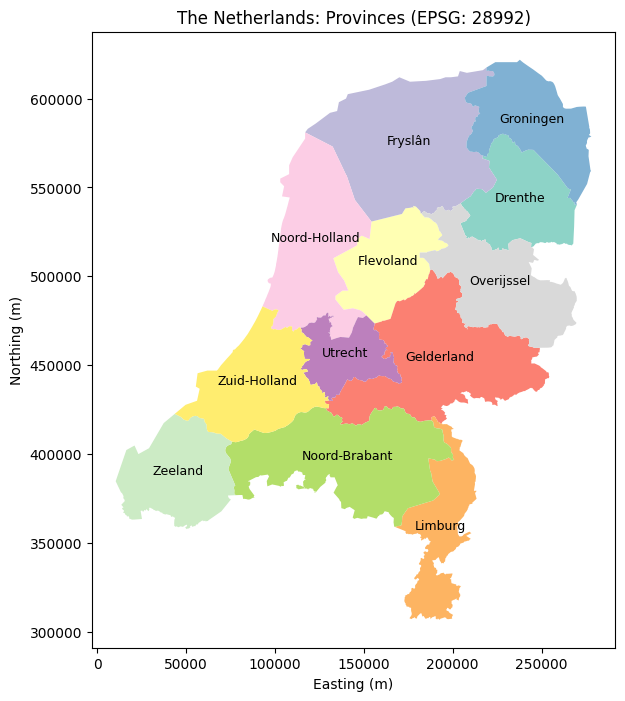

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
provinces.plot(ax=ax, cmap='Set3')

for row in provinces.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('The Netherlands: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

## Inspecting the Dutch Municipalities GeoPackage Layer

In [7]:
cities = gpd.read_file(f'{data_folder}/nederland_admin_areas.gpkg', layer='cities')
cities.shape

(342, 6)

In [8]:
cities.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
0,GM0263,Maasdriel,0263,25,Gelderland,"MULTIPOLYGON (((146637.319 416737.822, 146600 ..."


## Visualising the Municipalities

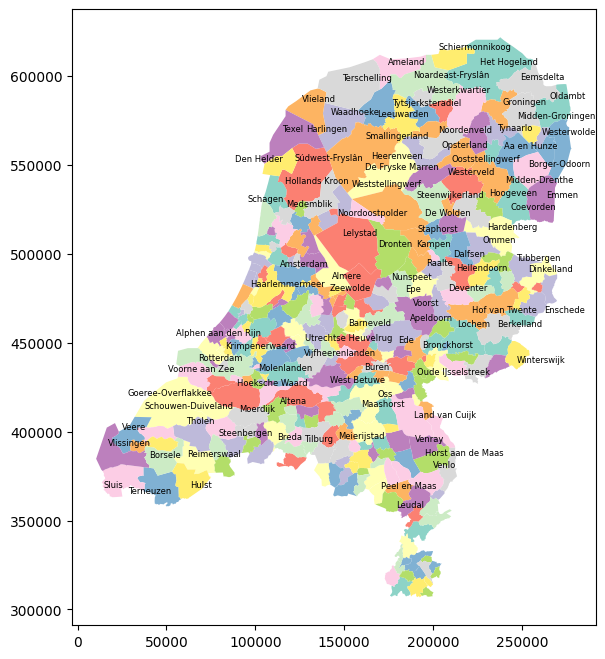

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
cities.plot(ax=ax, cmap='Set3')

texts = []

for row in cities.itertuples():
    area = row.geometry.area / 10**6
    if area > 125:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        text = ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=6)
        texts.append(text)

adjust_text(texts)
plt.show()

## Spatial Join: Contains

In [10]:
joined_gdf = provinces.sjoin(cities, how='left', predicate='contains')
joined_gdf.shape

(342, 12)

In [11]:
joined_gdf.head(1)

,identificatie_left,naam_left,code_left,ligt_in_land_code,ligt_in_land_naam,geometry,index_right,identificatie_right,naam_right,code_right,ligt_in_provincie_code,ligt_in_provincie_naam
0,PV22,Drenthe,22,6030,Nederland,"MULTIPOLYGON (((231437.815 516445.643, 231438....",248,GM1690,De Wolden,1690,22,Drenthe


In [12]:
grouped_gdf = joined_gdf.groupby(by='naam_left')
len(grouped_gdf)

12

In [13]:
city_count = grouped_gdf['naam_right'].count().reset_index()
city_count

,naam_left,naam_right
0,Drenthe,12
1,Flevoland,6
2,Fryslân,18
3,Gelderland,51
4,Groningen,10
5,Limburg,31
6,Noord-Brabant,56
7,Noord-Holland,44
8,Overijssel,25
9,Utrecht,26


In [14]:
city_count['naam_right'].sum()

np.int64(342)

In [15]:
provinces = provinces.merge(city_count, how='left', left_on='naam', right_on='naam_left')
provinces = provinces.rename(columns={'naam_right': 'city_count'})

provinces.head(1)

,identificatie,naam,code,ligt_in_land_code,ligt_in_land_naam,geometry,naam_left,city_count
0,PV22,Drenthe,22,6030,Nederland,"MULTIPOLYGON (((231437.815 516445.643, 231438....",Drenthe,12


## GeoDataFrame Cleaning

In [16]:
provinces = provinces[['naam', 'city_count', 'geometry']]
provinces.head(1)

,naam,city_count,geometry
0,Drenthe,12,"MULTIPOLYGON (((231437.815 516445.643, 231438...."


## Plotting the Final Results

### Bar Chart

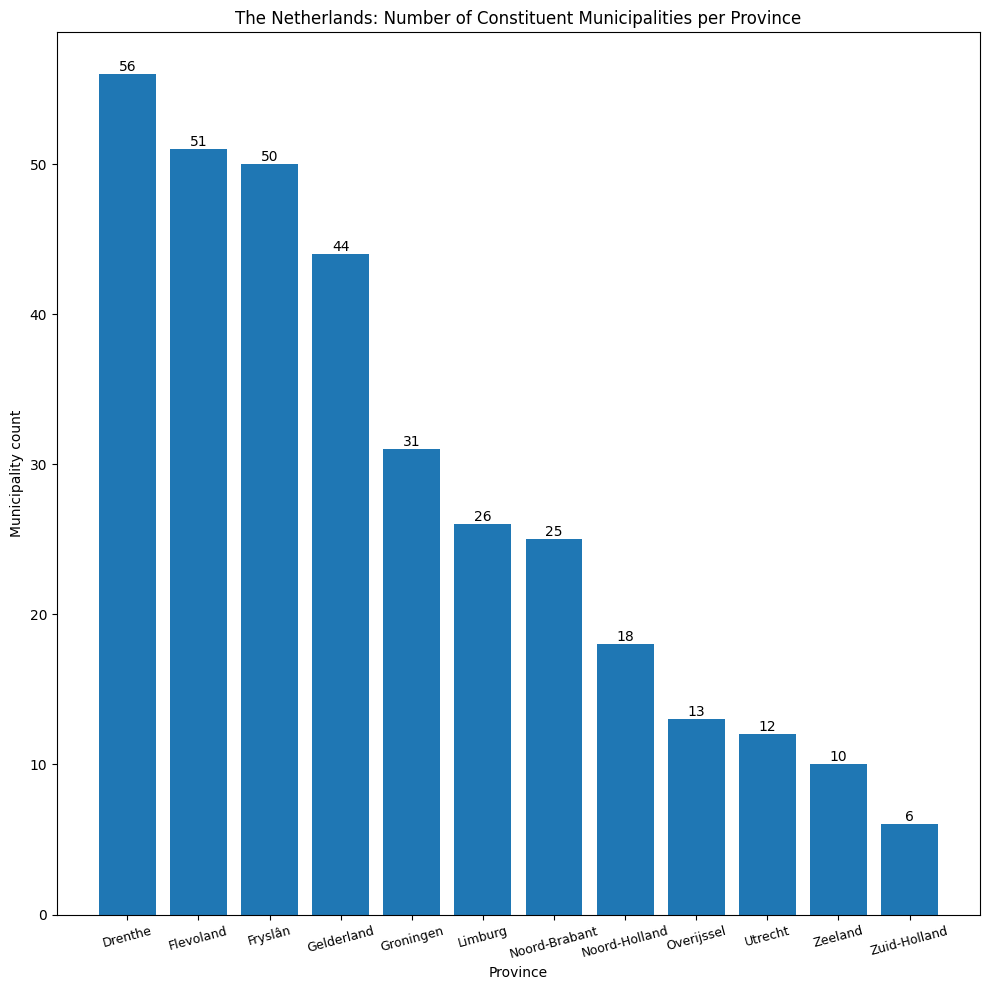

In [55]:
fig, ax = plt.subplots(figsize=(10,10))
bar = ax.bar(provinces['naam'], provinces['city_count'].sort_values(ascending=False))

ax.set_title('The Netherlands: Number of Constituent Municipalities per Province')
ax.set_xlabel('Province')
ax.set_ylabel('Municipality count')

ax.tick_params(axis='x', labelsize=9, labelrotation=15)
ax.bar_label(bar)

plt.tight_layout()
plt.show()

### Map

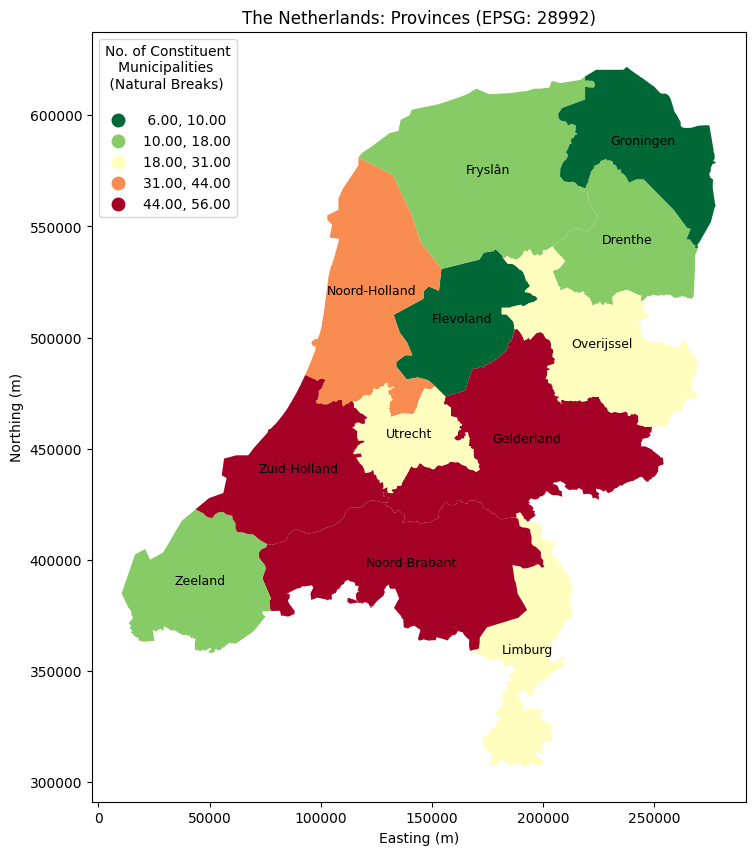

In [18]:
fig, ax = plt.subplots(figsize=(10,10))
provinces.plot(
    ax=ax, 
    column='city_count', 
    scheme='naturalbreaks', 
    k=5, 
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={
        'title': 'No. of Constituent\n   Municipalities\n (Natural Breaks)\n',
    }
)

for row in provinces.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('The Netherlands: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()